# 06 - Multi-Agent Orkestrasyon

Adım 9: birden fazla agent, agent'lar arası iletişim, görev dağıtımı.

- Message + MessageBus (Mediator): agent'lar birbirini doğrudan çağırmaz; her mesaj bus'tan geçer ve kaydedilir (agent izi).
- Yetenek kaydı: her agent görevlerini, ön koşullarını, girdi ve çıktılarını beyan eder; orchestrator görev -> agent eşlemesini buradan bulur.
- Planlama (hibrit): önce deterministik niyet yönlendiricisi, eşleşmezse yerel LLM (qwen2.5:3b) hedef görevi seçer; plan doğrulanır ve
  ön koşullarla tamamlanır.
- Dinamik dağıtım: doğrulama başarısızsa akış durur, karar ALLOW ise maliyetli LLM soruşturması atlanır, agent hatası sistemi çökertmez.
- Agent-to-agent: InvestigatorAgent açıklamadan önce FeatureAgent'tan kullanıcı profilini ister.

Agent'lar iş mantığı içermez: Adım 1-8'in modüllerini çağırır.

In [1]:
import json
import logging
import time

import matplotlib.pyplot as plt
import pandas as pd

from fraud_platform.agents.factory import build_agent_system
from fraud_platform.config import PROJECT_ROOT, get_settings
from fraud_platform.rag.factory import build_llm, load_pipeline
from fraud_platform.rules.engine import RuleEngine
from fraud_platform.services.scoring_service import ScoringService

logging.disable(logging.INFO)
pd.set_option("display.max_colwidth", 120)
IMG = PROJECT_ROOT / "docs" / "images"
settings = get_settings()

llm = build_llm(settings)
orchestrator = build_agent_system(settings, ScoringService.from_artifacts(settings), RuleEngine(settings.rules.rules_file),
                                  load_pipeline(settings, llm), llm)
bus = orchestrator.bus
print("planlama modu:", orchestrator.planner.mode, "| soruşturma kararları:", orchestrator.investigate_on)

planlama modu: hybrid | soruşturma kararları: ('BLOCK', 'REVIEW', 'FLAG')


## 1. Agent'lar ve yetenek kaydı

In [2]:
pd.DataFrame([{"agent": agent, "görev": task, "ön koşul": ", ".join(c.requires), "girdi": ", ".join(c.inputs),
               "çıktı": ", ".join(c.provides), "işlem gerekli": c.needs_transaction, "açıklama": c.description}
              for task, (agent, c) in bus.capabilities().items()])

,agent,görev,ön koşul,girdi,çıktı,işlem gerekli,açıklama
0,orchestrator,handle_request,,,,False,Kullanıcı isteğini planlayıp ilgili agent'lara dağıtır
1,data_agent,validate_transaction,,transaction,validation,True,İşlemin zorunlu alanlarını ve tiplerini kontrol eder
2,data_agent,dataset_summary,,,dataset,False,"Eğitim verisinin boyutu, eksiklik ve kalite özetini verir"
3,feature_agent,build_features,validate_transaction,transaction,"features, uid, key_features",True,İşlemin 55 feature'ını kullanıcı ve cihaz geçmişiyle üretir
4,feature_agent,get_entity_profile,,uid,profile,False,Bir kullanıcının (uid) geçmiş davranış özetini verir
5,scoring_agent,score,build_features,features,"score, assessment",False,"Anomali skoru, katman yüzdelikleri, context düzeltmesi ve dedektör gerekçeleri"
6,rule_agent,evaluate_rules,score,"assessment, strategy",rules,False,"Kural kararı, tetiklenen kurallar, kazanan kural ve çakışma çözümü"
7,investigator_agent,investigate,evaluate_rules,"score, rules",investigation,False,Verilen işlemin kararını politikalara dayanarak açıklar (neden bu karar)
8,investigator_agent,answer_policy_question,,question,answer,False,"İşlemden bağımsız genel politika sorusunu cevaplar (bir işlemin açıklaması için değil, onun için investigate)"


## 2. Planlayıcı değerlendirmesi

16 istek (12'si anahtar kelimeler ayarlanırken kullanıldı, 4'ü holdout: hiç görülmemiş ifadeler). Tam plan eşleşmesi.
`python scripts/eval_planner.py` ile üretildi.

In [3]:
ev = json.loads((settings.paths.artifacts_dir / "planner_eval.json").read_text(encoding="utf-8"))
display(pd.Series(ev["summary"]).round(3).to_frame("doğruluk"))
pd.DataFrame(ev["rows"])[["goal", "holdout", "beklenen", "llm", "rules", "hybrid", "hybrid_kaynak"]]

,doğruluk
hybrid_ayarlanan_12,1.000
hybrid_holdout_4,0.500
hybrid_tümü,0.875
llm_ayarlanan_12,0.833
llm_holdout_4,0.500
llm_tümü,0.750
rules_ayarlanan_12,1.000
rules_holdout_4,0.250
rules_tümü,0.812


,goal,holdout,beklenen,llm,rules,hybrid,hybrid_kaynak
0,Bu işlemi değerlendir ve kararın nedenini açıkla,False,investigate,evaluate_rules,investigate,investigate,rules
1,Sadece bu işlemin risk skorunu ver,False,score,score,score,score,rules
2,Bu işlem bloklanmalı mı?,False,evaluate_rules,answer_policy_question,evaluate_rules,evaluate_rules,rules
3,İşlemin kural motoru kararı nedir?,False,evaluate_rules,evaluate_rules,evaluate_rules,evaluate_rules,rules
4,"Bu işlem neden şüpheli bulundu, politikalara göre anlat",False,investigate,investigate,investigate,investigate,rules
5,Anomali skoru kaç?,False,score,score,score,score,rules
6,Bu işlemin alanları eksiksiz ve geçerli mi?,False,validate_transaction,validate_transaction,validate_transaction,validate_transaction,rules
7,Bu işlemin feature'larını hesapla,False,build_features,build_features,build_features,build_features,rules
8,FP-12 politikası cihaz paylaşımında ne yapılmasını söylüyor?,False,answer_policy_question,answer_policy_question,answer_policy_question,answer_policy_question,llm
9,Yeni kart politikasında günlük limit ne kadar?,False,answer_policy_question,answer_policy_question,answer_policy_question,answer_policy_question,default


İlk sürümde LLM'den tam görev listesi isteniyordu: 3B model gereksiz görev ekliyordu (%67). Tek bir hedef görev seçtirmek
(niyet sınıflandırması; ön koşulları onarım ekler) %83'e çıkardı. Anahtar kelime yönlendiricisi ayarlandığı sette %100 ama görülmemiş
ifadelerde %25; LLM %50. Hibrit ikisini birleştiriyor (toplam %88). Kalan hata: "Bu işlem dolandırıcılık mı?" LLM tarafından genel
politika sorusu sanılıyor.

> **Yorum:** Planlayıcıyı iki kez değiştirdim. İlk sürümde LLM'den tam görev listesi istedim, 3B model gereksiz görevler ekliyordu (%67).
> Sadece hedef görevi seçtirip ön koşulları koda bırakınca %83'e çıktı. Anahtar kelime yönlendiricisi ayarlandığı 12 istekte doğal
> olarak %100 ama görülmemiş 4 ifadede %25; LLM orada %50. Hibrit ikisini birleştiriyor (toplam %88). Holdout'taki iki hata:
> "Bu işlem dolandırıcılık mı?" genel politika sorusu sanılıyor, "Bu ödemeye güvenebilir miyiz?" kural kararı yerine sadece skora
> gidiyor. Holdout seti çok küçük; bu sayıları kesin sonuç değil eğilim olarak okuyorum.

## 3. Senaryolar

In [4]:
merged = pd.read_parquet(settings.merged_path)

def transaction(tx_id):
    row = merged.loc[merged[settings.data.id_column] == tx_id].drop(columns=settings.data.target_column).iloc[0]
    return {k: (None if pd.isna(v) else (v.item() if hasattr(v, "item") else v)) for k, v in row.items()}

def show(result, elapsed):
    print(f"durum: {result['status']} | {elapsed:.1f} sn | plan [{result['plan']['source']}]: {' -> '.join(result['plan']['tasks'])}")
    if result.get("decision"):
        print(f"karar: {result['decision']} | risk yüzdeliği: {result['risk_percentile']}")
    for s in result["steps"]:
        if s["status"] != "ok":
            print(f"  {s['task']}: {s['status']} {s.get('reason') or s.get('error') or ''}")
    trace = pd.DataFrame(result["trace"])[["kind", "from", "to", "task", "status", "duration_ms"]]
    return trace

def run(goal, tx_id=None, **kw):
    start = time.time()
    result = orchestrator.run(goal, transaction=transaction(tx_id) if tx_id else None, **kw)
    return result, show(result, time.time() - start)

### 3.1 Tam değerlendirme (BLOCK): agent'tan agent'a mesaj

In [5]:
full, trace = run("Bu işlemi değerlendir ve kararın nedenini açıkla", 3554906)
trace

durum: ok | 8.1 sn | plan [rules]: validate_transaction -> build_features -> score -> evaluate_rules -> investigate
karar: BLOCK | risk yüzdeliği: 0.99993


,kind,from,to,task,status,duration_ms
0,request,user,orchestrator,handle_request,ok,NaN
1,request,orchestrator,data_agent,validate_transaction,ok,NaN
2,reply,data_agent,orchestrator,validate_transaction,ok,37.0
3,request,orchestrator,feature_agent,build_features,ok,NaN
4,reply,feature_agent,orchestrator,build_features,ok,152.0
5,request,orchestrator,scoring_agent,score,ok,NaN
6,reply,scoring_agent,orchestrator,score,ok,310.4
7,request,orchestrator,rule_agent,evaluate_rules,ok,NaN
8,reply,rule_agent,orchestrator,evaluate_rules,ok,20.6
9,request,orchestrator,investigator_agent,investigate,ok,NaN


In [6]:
inv = full["investigation"]
print(inv["explanation"])
print("\natıflar:", inv["citations"], "| doğrulandı:", inv["citations_verified"], "| motorla aynı:", inv["llm_agrees_with_engine"])

Bu işlem, çok yüksek anomali skoruyla BLOCK edildi. Bu karar, [FP-01] Model Tabanlı Anomali Alarmları politikasına dayanarak verdi. Anomali skoru en uç %0,1'de (risk yüzdeliği 0.9999) olduğundan, bu durum çok riskli ve dolandırıcılık olasılığı yüksek olduğu için BLOCK edildi. Ayrıca, kullanıcı geçmişte 5 farklı cihaz kullanmış olması ve son 24 saatte 10 işlem daha var olması, Velocity politikasıyla ilişkilendirilebilir.

atıflar: ['FP-01'] | doğrulandı: True | motorla aynı: True


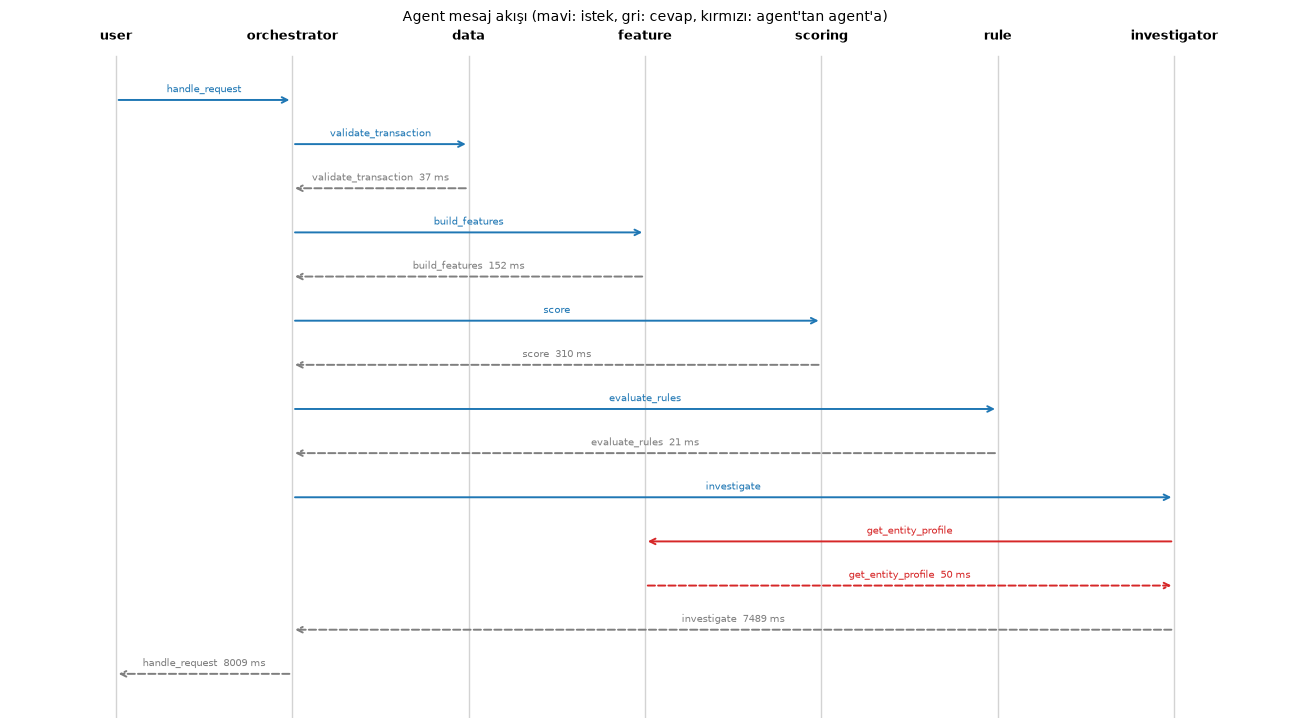

In [7]:
# sıra diyagramı: mesaj izinden
agents = ["user", "orchestrator", "data_agent", "feature_agent", "scoring_agent", "rule_agent", "investigator_agent"]
x = {a: i for i, a in enumerate(agents)}
events = full["trace"]
fig, ax = plt.subplots(figsize=(13, 0.42 * len(events) + 1.5))
for a in agents:
    ax.plot([x[a], x[a]], [0, len(events) + 1], color="lightgray", lw=1, zorder=0)
    ax.text(x[a], -0.3, a.replace("_agent", ""), ha="center", va="bottom", fontsize=9, fontweight="bold")
for i, e in enumerate(events, start=1):
    color = "tab:red" if e["task"] == "get_entity_profile" else ("tab:blue" if e["kind"] == "request" else "tab:gray")
    ax.annotate("", xy=(x[e["to"]], i), xytext=(x[e["from"]], i),
                arrowprops=dict(arrowstyle="->", color=color, lw=1.4, ls="-" if e["kind"] == "request" else "--"))
    label = e["task"] + (f"  {e['duration_ms']:.0f} ms" if e["duration_ms"] else "")
    ax.text((x[e["to"]] + x[e["from"]]) / 2, i - 0.12, label, ha="center", va="bottom", fontsize=7.5, color=color)
ax.set_ylim(len(events) + 1, -0.6)
ax.set_xlim(-0.6, len(agents) - 0.4)
ax.axis("off")
ax.set_title("Agent mesaj akışı (mavi: istek, gri: cevap, kırmızı: agent'tan agent'a)", fontsize=10)
plt.tight_layout()
fig.savefig(IMG / "09_agent_sequence.png", dpi=120)

> **Yorum:** Tam akışta 6 agent mesajlaşıyor: doğrulama -> feature -> skor -> kural -> soruşturma. Kırmızı ok agent'tan agent'a iletişim:
> investigator, açıklamayı yazmadan önce feature agent'tan kullanıcı profilini istiyor ve bu profil LLM'in açıklamasına giriyor
> ("5 farklı cihaz, son 24 saatte 10 işlem"). Toplam 8 sn'nin ~7,5 sn'si LLM soruşturması; doğrulama, feature, skor ve kural
> birlikte yarım saniye civarında. Bu yüzden LLM'i sadece gerektiğinde çalıştırmak önemli.

### 3.2 ALLOW kararı: soruşturma atlanır (maliyet) / zorlanabilir

In [8]:
allow, trace = run("Bu ödemeye güvenebilir miyiz, nedenini açıkla", 3577539)
forced, _ = run("Bu ödemeye güvenebilir miyiz, nedenini açıkla", 3577539, force_investigation=True)
print("\nzorlanmış soruşturma açıklaması:", forced["investigation"]["explanation"][:300])

durum: ok | 0.5 sn | plan [rules]: validate_transaction -> build_features -> score -> evaluate_rules -> investigate
karar: ALLOW | risk yüzdeliği: 0.910747
  investigate: skipped karar ALLOW: LLM soruşturması gerekmiyor (maliyet)


durum: ok | 8.1 sn | plan [rules]: validate_transaction -> build_features -> score -> evaluate_rules -> investigate
karar: ALLOW | risk yüzdeliği: 0.910747

zorlanmış soruşturma açıklaması: [FP-07] politikada, kart aktivasyonundan sonraki ilk 7 gün içinde 500 USD üzerindeki işlemler yeni kart riski taşır ve FLAG olarak izlenir. Bu süre içinde kart başına günlük toplam limit 1500 USD'dir. Ürün grubu W dışındaki işlemlerde kart yaşı bilgisi güvenilir olmadığından bu politika yalnızca W ü


### 3.3 Sadece skor: kısa plan

In [9]:
_, trace = run("Sadece bu işlemin risk skorunu ver", 3554906)
trace

durum: ok | 0.4 sn | plan [rules]: validate_transaction -> build_features -> score


,kind,from,to,task,status,duration_ms
0,request,user,orchestrator,handle_request,ok,NaN
1,request,orchestrator,data_agent,validate_transaction,ok,NaN
2,reply,data_agent,orchestrator,validate_transaction,ok,18.0
3,request,orchestrator,feature_agent,build_features,ok,NaN
4,reply,feature_agent,orchestrator,build_features,ok,100.0
5,request,orchestrator,scoring_agent,score,ok,NaN
6,reply,scoring_agent,orchestrator,score,ok,301.6
7,reply,orchestrator,user,handle_request,ok,420.6


### 3.4 Anahtar kelime eşleşmeyen istek: karar LLM'de

In [10]:
r, trace = run("Bu harcama ne kadar tuhaf?", 3554906)
print("LLM gerekçesi:", r["plan"]["reason"])

durum: ok | 0.9 sn | plan [llm]: validate_transaction -> build_features -> score
LLM gerekçesi: İşlemin anormal olup olmadığını belirleme için gereken görev


### 3.5 İşlemsiz politika sorusu

In [11]:
r, _ = run("Kart test saldırısında cihaz ne kadar süre gözetimde kalır?")
print(r["answer"]["answer"], "\natıf doğrulandı:", r["answer"]["citations_verified"])

durum: ok | 4.9 sn | plan [default]: answer_policy_question
[FP-12] Kart test (card testing) saldırısı, aynı cihaz parmak izi üzerinden daha önce 5 veya daha fazla farklı kart kullanılmış olması göstergesidir. Anomali skoru da yüksekse (risk yüzdeliği 0,90 ve üzeri), işlem [FP-12] FLAG olarak izlenir ve cihaz parmak izi 48 saat boyunca gözetim listesine alınır. Gözetim listesindeki bir cihazdan yeni bir kartla yapılan ilk işlem otomatik olarak REVIEW'a gönderilir. 
atıf doğrulandı: True


### 3.6 Geçersiz işlem: akış doğrulamada durur

In [12]:
bad = transaction(3554906) | {"TransactionAmt": None, "card1": "abc"}
r = orchestrator.run("Bu işlemi değerlendir", transaction=bad)
print("durum:", r["status"], "|", r["error"])
print("çalışan adımlar:", [s["task"] for s in r["steps"]])

durum: invalid | işlem doğrulanamadı: zorunlu alan eksik: TransactionAmt
çalışan adımlar: ['validate_transaction']


> **Yorum:** Senaryolar dinamik dağıtımı gösteriyor. ALLOW kararında LLM soruşturması atlanıyor (8,1 sn -> 0,5 sn), istenirse zorlanabiliyor.
> Zorlanan açıklamada model, ALLOW verilmiş bir işlem için yeni kart politikasını anlatıyor; ALLOW'da soruşturmayı atlamanın bir
> sebebi de bu. "Sadece risk skoru" isteğinde plan skorda bitiyor (0,4 sn). Anahtar kelimeye uymayan "Bu harcama ne kadar tuhaf?"
> isteğinde planı LLM seçti ve doğru görevi (skor) buldu. İşlemsiz politika sorusu doğrudan RAG'e gidiyor. Zorunlu alanı eksik
> işlemde akış doğrulamada duruyor ve hata mesajı dönüyor; sonraki agent'lar hiç çalışmıyor.

## 4. Sınırlamalar

- Bus senkron ve tek süreç içi: ölçekte kuyruk (Redis/Kafka) ve asenkron agent'lar gerekir; arayüz (send/route/trace) aynı kalır.
- Planlayıcı 3B modelle %88 (hibrit); niyet hataları onarımla düzeltilemez (geçerli ama yanlış görev). Holdout seti küçük (4 istek).
- LLM sadece planlamada (belirsiz isteklerde) ve açıklamada; karar her zaman deterministik kural motorunda.
- Paylaşılan durum (state) orchestrator'da; agent'lar durumsuz, bu yüzden yeniden denenebilir ve test edilebilir.

## 5. Özet

Çıktılar: `src/fraud_platform/agents/`, `scripts/run_agents_demo.py`, `scripts/eval_planner.py`, `artifacts/agent_traces/`, `docs/images/09_agent_sequence.png`

- Agent'lar: orchestrator + 5 agent (veri, feature, skor, kural, soruşturma); her biri Adım 1-8'in modüllerini çağırıyor, iş mantığı içermiyor.
- İletişim: mesajlar bus üzerinden (Mediator), her mesaj ve süresi izde; iz API cevabında da dönüyor.
- Yetenek kaydı: görevler, ön koşullar, girdi ve çıktılar agent'larda beyan ediliyor; orchestrator'da sabit tablo yok.
- Planlama: hibrit (anahtar kelime -> LLM -> varsayılan), 16 istekte %88; LLM tek hedef görev seçiyor, ön koşulları onarım ekliyor.
- Dinamik dağıtım ve hata yönetimi: ALLOW'da soruşturma atlanıyor, geçersiz işlemde akış duruyor, agent hatası sistemi çökertmiyor.
- Karar kural motorunda; LLM sadece belirsiz isteğin planında ve açıklamada.